# 07 - SKU-Aware Trigger Engine

Normaliza a forca de selagem pela demanda especifica de cada SKU (produto embalado).

| Etapa | Descricao |
|---|---|
| A | Carregar e explorar `sku_dates.csv` (2022-2026 completo) |
| B | Calibrar fatores de stress por SKU (bag1) |
| C | Normalizar forca historica -> `Media_norm` |
| D | Backtest p_risk com forca normalizada vs v2 raw |
| E | SKUs futuros simulados - projecao SKU-aware |
| F | Figura consolidada para gestores |

In [1]:
import sys, warnings, tempfile
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path
from datetime import datetime, timedelta

from src.sku_normalizer import (
    SKU_CATALOG, get_sku_factor, normalizar_media,
    upcoming_sku_factor, proj_48h_ajustada, resumo_catalog, UPCOMING_SKUS
)
from src.trigger_engine import TriggerEngine, LIMIAR_P_RISK, WEIBULL_BETA, WEIBULL_ETA_D

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white', 'axes.facecolor': '#F9F9F9',
})

COR_RAW   = '#2B6CB0'
COR_NORM  = '#C05621'
COR_PRISK = '#C53030'
COR_TROCA = '#276749'
COR_RED   = '#E53E3E'
COR_SKU   = '#6B21A8'

print('Modulos OK')


Modulos OK


## Etapa A - Carregar sku_dates.csv (2022-2026 completo)

In [2]:
# Carregar SKU
sku_raw = pd.read_csv('sku_dates.csv')
sku_raw['ts'] = pd.to_datetime(sku_raw['index'], utc=True).dt.tz_convert(None)
sku_raw = sku_raw.sort_values('ts').reset_index(drop=True)

print(f"SKU data: {len(sku_raw)} linhas | {sku_raw['ts'].min().date()} a {sku_raw['ts'].max().date()}")
print(f"SKUs unicos (bag1): {sku_raw['bag1_sku'].nunique()}")
print(f"SKUs unicos (bag2): {sku_raw['bag2_sku'].nunique()}")

# Carregar forca horaria
hora = pd.read_csv('00_hour_prev.csv', parse_dates=['Timestamp'])
hora['Timestamp'] = pd.to_datetime(hora['Timestamp'], utc=True).dt.tz_localize(None)
hora = hora.set_index('Timestamp').sort_index()
print(f"\nForca horaria: {len(hora)} linhas | {hora.index.min().date()} a {hora.index.max().date()}")

# Trocas
tc = pd.read_csv('../troca_modulo.csv', parse_dates=['Data-base do inicio'])
troca_dates = sorted([t.replace(tzinfo=None)
    for t in pd.to_datetime(tc['Data-base do inicio']).dt.to_pydatetime()])
print(f"Trocas: {len(troca_dates)} | ultima: {troca_dates[-1].date()}")
ultima_troca = troca_dates[-1]
hoje = pd.Timestamp('2026-05-09')


SKU data: 13957 linhas | 2022-05-10 a 2026-05-09
SKUs unicos (bag1): 60
SKUs unicos (bag2): 51



Forca horaria: 3209 linhas | 2022-06-27 a 2026-05-07
Trocas: 31 | ultima: 2026-05-06


In [3]:
# Distribuicao de SKUs por ano
sku_raw['ano'] = sku_raw['ts'].dt.year
por_ano = sku_raw.groupby('ano')['bag1_sku'].nunique().rename('SKUs_unicos_bag1')
print('SKUs unicos (bag1) por ano:')
print(por_ano.to_string())
print()
sku_2026 = sku_raw[sku_raw['ano'] == 2026]
print(f"2026 - {len(sku_2026)} registros | {sku_2026['ts'].min().date()} a {sku_2026['ts'].max().date()}")
print(f"bag1_sku em 2026: {sorted(sku_2026['bag1_sku'].dropna().astype(int).unique().tolist())}")
print(f"bag2_sku em 2026: {sorted(sku_2026['bag2_sku'].dropna().astype(int).unique().tolist())}")


SKUs unicos (bag1) por ano:
ano
2022    21
2023    15
2024    19
2025    26
2026    13

2026 - 1232 registros | 2026-01-01 a 2026-05-09
bag1_sku em 2026: [30246795, 30246805, 30246806, 30246808, 30246815, 30246818, 30246822, 30246823, 30246824, 30246827, 30246850, 30246860, 30246872]
bag2_sku em 2026: [30246808, 30246817, 30246825, 30246826, 30246839, 30246844]


## Etapa B - Calibrar fatores de stress por SKU

In [4]:
# Merge SKU x forca para calibracao
merged_cal = pd.merge_asof(
    hora.reset_index().sort_values('Timestamp'),
    sku_raw[['ts','bag1_sku','bag2_sku']].sort_values('ts'),
    left_on='Timestamp', right_on='ts',
    direction='nearest',
    tolerance=pd.Timedelta('3h')
)
merged_cal = merged_cal.dropna(subset=['bag1_sku','Media'])

media_global = merged_cal['Media'].mean()
sku_stats = (merged_cal.groupby('bag1_sku')['Media']
             .agg(['mean','std','count'])
             .rename(columns={'mean':'media_N','std':'std_N','count':'n'})
             .reset_index())
sku_stats['fator_obs']     = (sku_stats['media_N'] / media_global).round(4)
sku_stats['fator_catalog'] = sku_stats['bag1_sku'].apply(get_sku_factor)
sku_stats = sku_stats[sku_stats['n'] >= 50].sort_values('fator_obs', ascending=False)

print(f"Media global de forca: {media_global:.0f} N")
print(f"SKUs com n >= 50: {len(sku_stats)}")
print()
print(sku_stats[['bag1_sku','media_N','std_N','n','fator_obs','fator_catalog']].to_string(index=False))
print()
rng = sku_stats['fator_obs'].max() / sku_stats['fator_obs'].min()
print(f"Range de fator: {sku_stats['fator_obs'].min():.3f} a {sku_stats['fator_obs'].max():.3f}  ({rng:.2f}x)")


Media global de forca: 1077 N
SKUs com n >= 50: 21

  bag1_sku     media_N      std_N   n  fator_obs  fator_catalog
30244719.0 1312.389051 309.413554 195     1.2190          1.217
30244780.0 1211.281374 257.603472 131     1.1251          1.123
30244746.0 1202.010194 259.926900 103     1.1165          1.115
30244771.0 1181.834462 264.589824 186     1.0978          1.096
30246818.0 1167.749206 254.992121 126     1.0847          1.083
30243813.0 1160.661765 325.909729  51     1.0781          1.076
30242124.0 1145.440761 293.788161  92     1.0640          1.062
30244770.0 1126.235369 228.921866 122     1.0461          1.044
30246823.0 1123.467000 244.507360  50     1.0436          1.000
30243615.0 1121.301875 276.876339 136     1.0415          1.040
30246872.0 1111.197242 243.848781 165     1.0322          1.030
30246850.0 1108.132456 220.823022  57     1.0293          1.028
30244716.0 1097.108494 216.402647  83     1.0191          1.017
30246824.0 1084.022464 240.750658 138     1.0069    

In [5]:
# Tabela catalogo
cat = resumo_catalog()
print('Catalogo SKU_CATALOG (src/sku_normalizer.py):')
print()
print(f"{'SKU':>12}  {'Fator':>7}  {'Demanda':>10}  {'Forca equiv 1100N':>18}")
print('-' * 56)
for _, r in cat.iterrows():
    forca_equiv = 1100 * r['fator']
    tag = 'PESADO' if r['demanda'] == 'pesado' else ('LEVE' if r['demanda'] == 'leve' else 'normal')
    print(f"{int(r['sku']):>12}  {r['fator']:>7.3f}  {tag:>10}  {forca_equiv:>8.0f} N")


Catalogo SKU_CATALOG (src/sku_normalizer.py):

         SKU    Fator     Demanda   Forca equiv 1100N
--------------------------------------------------------
    30244719    1.217      PESADO      1339 N
    30244780    1.123      PESADO      1235 N
    30244746    1.115      PESADO      1226 N
    30244771    1.096      PESADO      1206 N
    30246818    1.083      PESADO      1191 N
    30243813    1.076      PESADO      1184 N
    30242124    1.062      PESADO      1168 N
    30244770    1.044      normal      1148 N
    30243615    1.040      normal      1144 N
    30246872    1.030      normal      1133 N
    30246850    1.028      normal      1131 N
    30244716    1.017      normal      1119 N
    30246824    1.005      normal      1105 N
    30243621    0.986      normal      1085 N
    30246822    0.923      normal      1015 N
    30243599    0.911      normal      1002 N
    30246827    0.907      normal       998 N
    30242137    0.890        LEVE       979 N
    30243609  

## Etapa C - Normalizar forca historica

In [6]:
# Aplicar normalizacao
df_norm = normalizar_media(hora, sku_raw[['ts','bag1_sku']], tolerancia='3h')
df_norm['Media_norm'] = df_norm['Media_norm'].clip(lower=0)

cobertura = df_norm['sku_fator'].notna().mean()
print(f"Cobertura da normalizacao: {cobertura*100:.1f}% dos registros")
print()
print('Estatisticas forca bruta (Media):')
print(df_norm['Media'].describe().round(0))
print()
print('Estatisticas forca normalizada (Media_norm):')
print(df_norm['Media_norm'].describe().round(0))
print()
ex_leve  = df_norm[df_norm['sku_codigo'] == 30241637.0]['Media'].mean()
ex_norm_ = df_norm[df_norm['sku_codigo'] == 30241637.0]['Media_norm'].mean()
print(f"Exemplo SKU leve (30241637, fator=0.557):")
print(f"  Media bruta: {ex_leve:.0f} N  ->  Media_norm: {ex_norm_:.0f} N (rolo saudavel)")


Cobertura da normalizacao: 100.0% dos registros

Estatisticas forca bruta (Media):
count    3209.0
mean     1077.0
std       275.0
min       398.0
25%       883.0
50%      1047.0
75%      1264.0
max      2295.0
Name: Media, dtype: float64

Estatisticas forca normalizada (Media_norm):
count    3209.0
mean     1067.0
std       243.0
min       433.0
25%       896.0
50%      1048.0
75%      1229.0
max      2295.0
Name: Media_norm, dtype: float64

Exemplo SKU leve (30241637, fator=0.557):
  Media bruta: 600 N  ->  Media_norm: 1078 N (rolo saudavel)


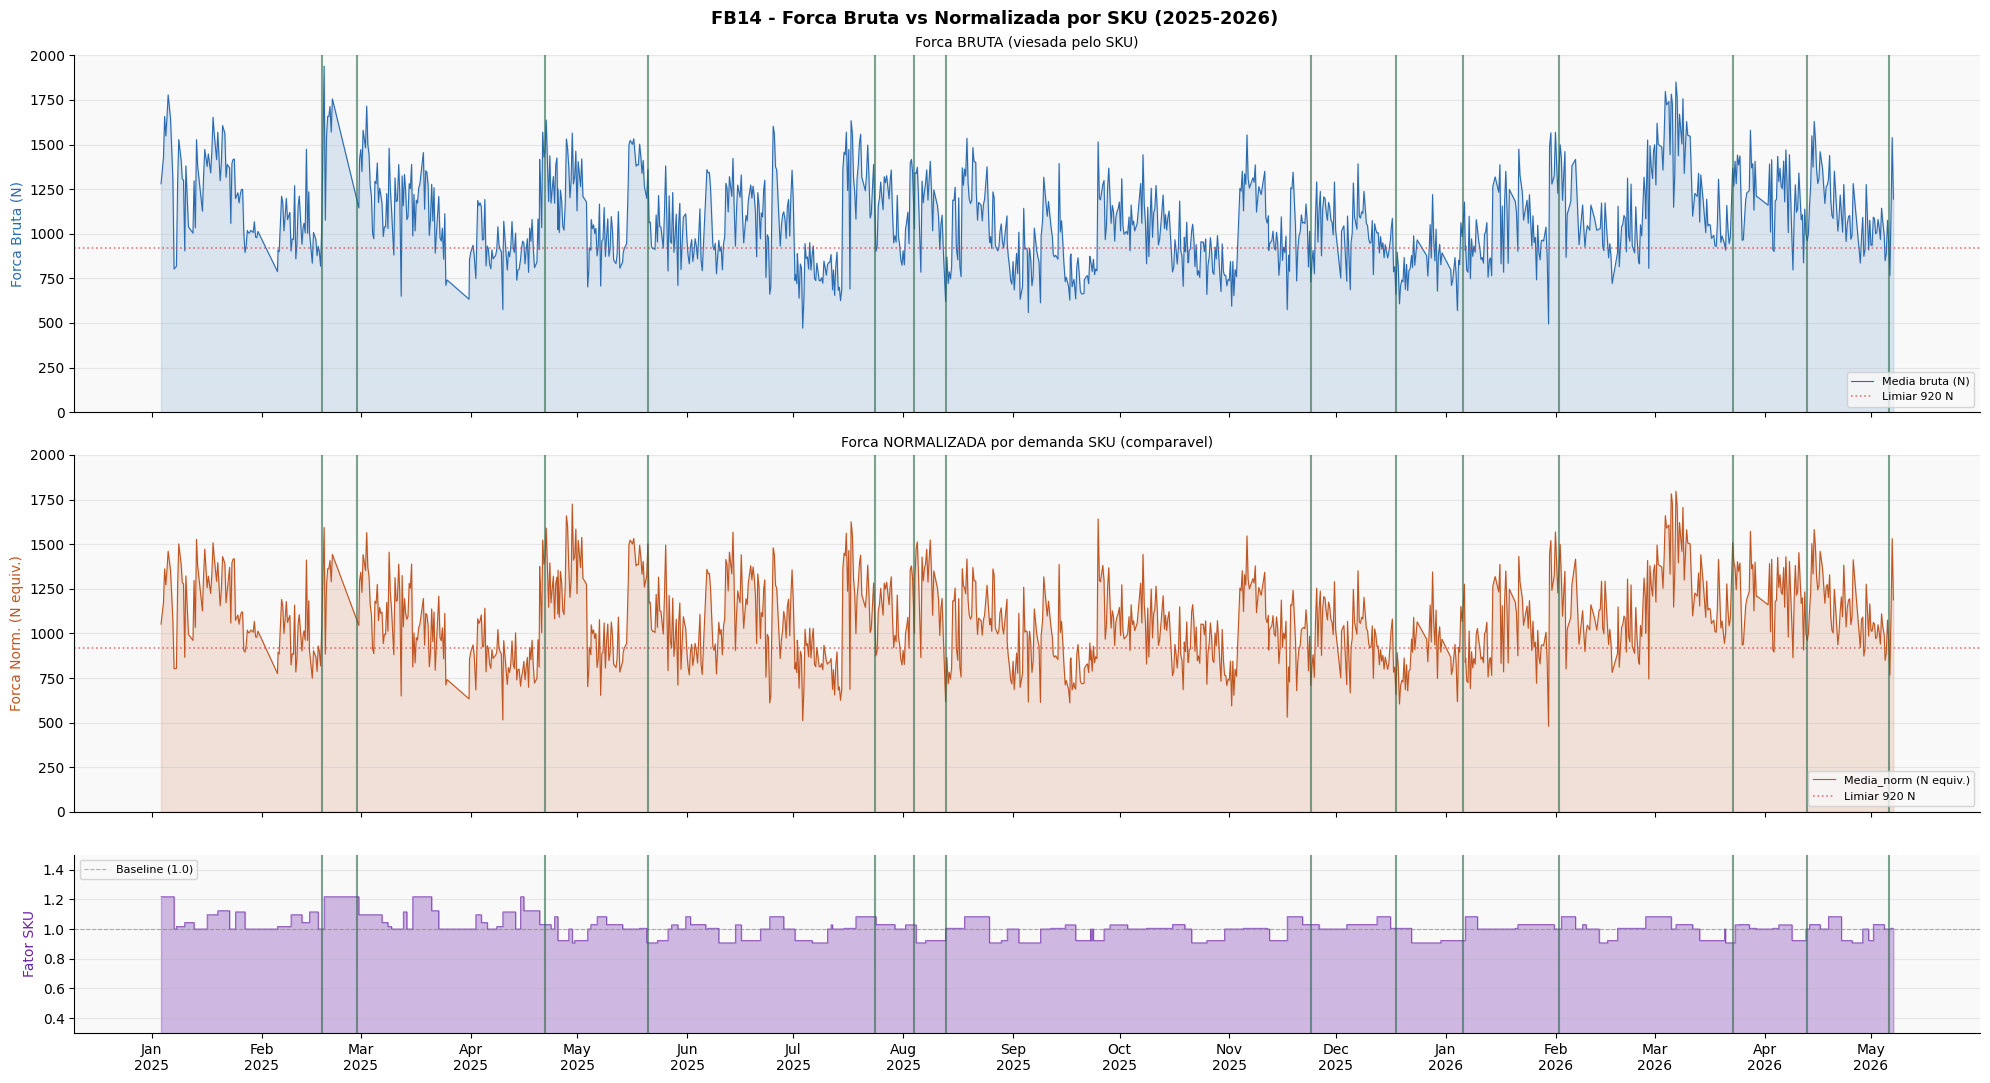

Figura 1 salva: 07_forca_raw_vs_norm.png


In [7]:
# Figura 1: Forca bruta vs normalizada
DATA_INI = datetime(2025, 1, 1)
DATA_FIM = datetime(2026, 5, 10)

df_v = df_norm[(df_norm.index >= DATA_INI) & (df_norm.index <= DATA_FIM)]
trocas_v = [t for t in troca_dates if DATA_INI <= t <= DATA_FIM]

fig, axes = plt.subplots(3, 1, figsize=(20, 11),
                          gridspec_kw={'height_ratios':[2,2,1]}, sharex=True)
fig.patch.set_facecolor('white')
fig.suptitle('FB14 - Forca Bruta vs Normalizada por SKU (2025-2026)', fontsize=13, fontweight='bold')

# Painel 1: bruta
ax0 = axes[0]
mask = df_v['Media'].notna()
ax0.fill_between(df_v[mask].index, df_v[mask]['Media'], color=COR_RAW, alpha=0.15)
ax0.plot(df_v[mask].index, df_v[mask]['Media'], lw=0.8, color=COR_RAW, label='Media bruta (N)')
ax0.axhline(920, color=COR_RED, ls=':', lw=1.2, alpha=0.7, label='Limiar 920 N')
ax0.set_ylabel('Forca Bruta (N)', fontsize=10, color=COR_RAW)
ax0.set_ylim(0, 2000)
ax0.legend(fontsize=8, loc='lower right')
ax0.set_title('Forca BRUTA (viesada pelo SKU)', fontsize=10)
ax0.grid(axis='y', alpha=0.25)

# Painel 2: normalizada
ax1 = axes[1]
mask2 = df_v['Media_norm'].notna()
ax1.fill_between(df_v[mask2].index, df_v[mask2]['Media_norm'], color=COR_NORM, alpha=0.15)
ax1.plot(df_v[mask2].index, df_v[mask2]['Media_norm'], lw=0.8, color=COR_NORM, label='Media_norm (N equiv.)')
ax1.axhline(920, color=COR_RED, ls=':', lw=1.2, alpha=0.7, label='Limiar 920 N')
ax1.set_ylabel('Forca Norm. (N equiv.)', fontsize=10, color=COR_NORM)
ax1.set_ylim(0, 2000)
ax1.legend(fontsize=8, loc='lower right')
ax1.set_title('Forca NORMALIZADA por demanda SKU (comparavel)', fontsize=10)
ax1.grid(axis='y', alpha=0.25)

# Painel 3: fator SKU
ax2 = axes[2]
mask3 = df_v['sku_fator'].notna()
ax2.fill_between(df_v[mask3].index, df_v[mask3]['sku_fator'], color=COR_SKU, alpha=0.3, step='post')
ax2.plot(df_v[mask3].index, df_v[mask3]['sku_fator'], lw=0.6, color=COR_SKU, alpha=0.7, drawstyle='steps-post')
ax2.axhline(1.0, color='gray', ls='--', lw=0.8, alpha=0.6, label='Baseline (1.0)')
ax2.set_ylabel('Fator SKU', fontsize=10, color=COR_SKU)
ax2.set_ylim(0.3, 1.5)
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.25)

for t in trocas_v:
    for ax in axes:
        ax.axvline(t, color=COR_TROCA, lw=1.5, alpha=0.6, zorder=4)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=0, ha='center')
plt.tight_layout()
plt.savefig('07_forca_raw_vs_norm.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Figura 1 salva: 07_forca_raw_vs_norm.png')


## Etapa D - Backtest p_risk: forca normalizada vs raw

In [8]:
from src.trigger_engine import compute_p_risk_snapshot

# df para o engine com Media_norm no lugar de Media
df_engine_norm = df_norm[['Media_norm']].copy()
if 'Forca_A' in hora.columns: df_engine_norm['Forca_A'] = hora['Forca_A']
if 'Forca_B' in hora.columns: df_engine_norm['Forca_B'] = hora['Forca_B']
df_engine_norm = df_engine_norm.rename(columns={'Media_norm': 'Media'})

results = {'raw': [], 'norm': []}

for i, (t_ini, t_fim) in enumerate(zip(troca_dates[:-1], troca_dates[1:])):
    for mode, df_use in [('raw', hora), ('norm', df_engine_norm)]:
        ciclo_df = df_use[(df_use.index >= t_ini) & (df_use.index < t_fim)]
        if ciclo_df.empty: continue
        state_path = Path(tempfile.mktemp(suffix='.json'))
        engine = TriggerEngine('FB14', state_path)
        dias = pd.DatetimeIndex(sorted({ts.normalize() for ts in ciclo_df.index}))
        for day in dias:
            df_ate = df_use[df_use.index <= day + pd.Timedelta(hours=23, minutes=59)]
            if df_ate.empty: continue
            try:
                evs = engine.evaluate(df_ate, t_ini, sp_client=None, today=day)
            except Exception:
                continue
            for ev in evs:
                results[mode].append({
                    'ciclo': i, 'day': day,
                    'troca_fim': t_fim, 'p_risk': ev.score_atual,
                    'ant': (t_fim - day).days,
                })
        if state_path.exists(): state_path.unlink()

ev_raw  = pd.DataFrame(results['raw'])
ev_norm = pd.DataFrame(results['norm'])

for nome, ev in [('v2-raw', ev_raw), ('v3-norm', ev_norm)]:
    if ev.empty:
        print(f'{nome}: sem eventos')
        continue
    print(f"{nome}: {len(ev)} alertas RED | {ev['ciclo'].nunique()}/30 ciclos | "
          f"antecedencia mediana {ev['ant'].median():.0f}d")


[dry-run] RED não persistido (sp_client=None).


[dry-run] RED não persistido (sp_client=None).


[dry-run] RED não persistido (sp_client=None).


[dry-run] RED não persistido (sp_client=None).


[dry-run] RED não persistido (sp_client=None).


...

[dry-run] RED não persistido (sp_client=None).


[dry-run] RED não persistido (sp_client=None).


[dry-run] RED não persistido (sp_client=None).


[dry-run] RED não persistido (sp_client=None).


v2-raw: 62 alertas RED | 16/30 ciclos | antecedencia mediana 28d
v3-norm: 61 alertas RED | 16/30 ciclos | antecedencia mediana 26d


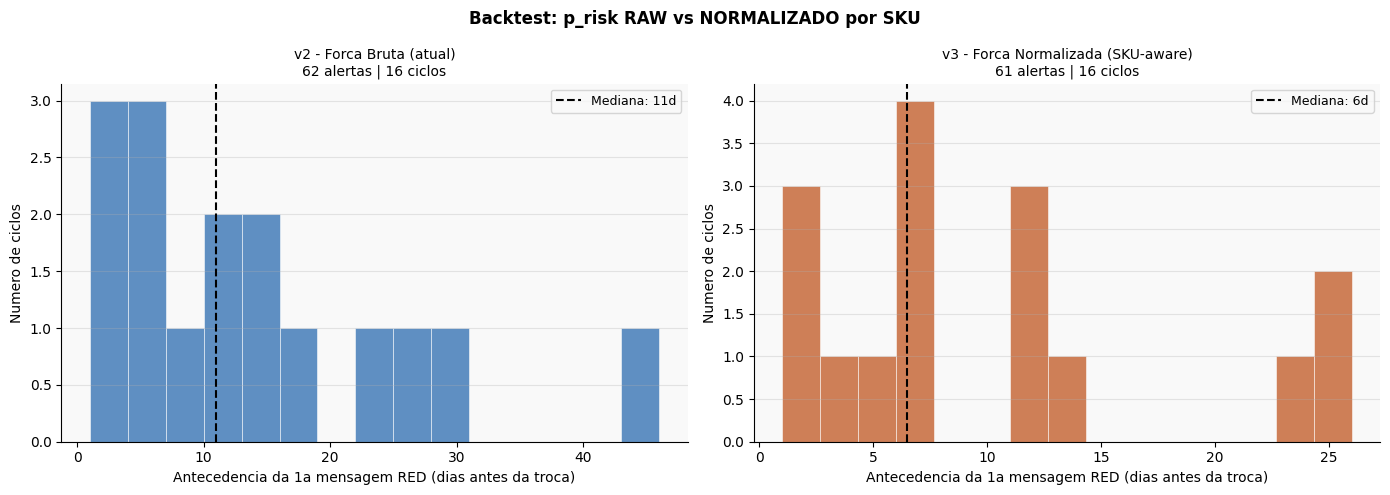

Figura 2 salva: 07_backtest_raw_vs_norm.png


In [9]:
# Figura 2: comparacao de antecedencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')
fig.suptitle('Backtest: p_risk RAW vs NORMALIZADO por SKU', fontsize=12, fontweight='bold')

for ax, (nome, ev, cor) in zip(axes, [
    ('v2 - Forca Bruta (atual)', ev_raw, COR_RAW),
    ('v3 - Forca Normalizada (SKU-aware)', ev_norm, COR_NORM),
]):
    if ev.empty:
        ax.text(0.5, 0.5, 'Sem eventos', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(nome); continue
    por_ciclo = ev.groupby('ciclo')['ant'].min().values
    ax.hist(por_ciclo, bins=15, color=cor, alpha=0.75, edgecolor='white', linewidth=0.5)
    med = np.median(por_ciclo)
    ax.axvline(med, color='black', ls='--', lw=1.5, label=f'Mediana: {med:.0f}d')
    ax.set_xlabel('Antecedencia da 1a mensagem RED (dias antes da troca)', fontsize=10)
    ax.set_ylabel('Numero de ciclos', fontsize=10)
    ax.set_title(f"{nome}\n{len(ev)} alertas | {ev['ciclo'].nunique()} ciclos", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('07_backtest_raw_vs_norm.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Figura 2 salva: 07_backtest_raw_vs_norm.png')


## Etapa E - SKUs futuros simulados: alerta SKU-aware

In [10]:
# SKUs futuros programados (5 simulados)
print('SKUs futuros programados (simulados):')
print()
print(f"{'Periodo':>25}  {'SKU':>12}  {'Fator':>7}  {'Demanda':>10}")
print('-' * 60)
for item in UPCOMING_SKUS:
    f = get_sku_factor(item['sku'])
    demanda = 'PESADO' if f > 1.05 else ('LEVE' if f < 0.90 else 'normal')
    print(f"  {item['data_inicio']} -> {item['data_fim']}  {item['sku']:>12}  {f:>7.3f}  {demanda:>10}")

print()
age_days = (hoje - ultima_troca).days
print(f"Estado atual: rolo trocado em {ultima_troca.date()} | idade = {age_days} dias")
print()
for janela in [7, 14, 30]:
    uf = upcoming_sku_factor(hoje, janela_dias=janela)
    txt = ('SKU pesado vindo - rolo trabalhara mais' if uf > 1.05
           else ('SKU leve vindo - forca bruta vai cair' if uf < 0.90 else 'SKU normal'))
    print(f"  Upcoming factor (proximos {janela:>2}d): {uf:.4f}  ({txt})")


SKUs futuros programados (simulados):

                  Periodo           SKU    Fator     Demanda
------------------------------------------------------------
  2026-05-09 -> 2026-05-18      30244719    1.217      PESADO
  2026-05-18 -> 2026-05-28      30243615    1.040      normal
  2026-05-28 -> 2026-06-08      30243621    0.986      normal
  2026-06-08 -> 2026-06-20      30242137    0.890        LEVE
  2026-06-20 -> 2026-07-05      30241637    0.557        LEVE

Estado atual: rolo trocado em 2026-05-06 | idade = 3 dias

  Upcoming factor (proximos  7d): 1.2170  (SKU pesado vindo - rolo trabalhara mais)
  Upcoming factor (proximos 14d): 1.1538  (SKU pesado vindo - rolo trabalhara mais)
  Upcoming factor (proximos 30d): 1.0733  (SKU pesado vindo - rolo trabalhara mais)


In [11]:
# Snapshot SKU-aware do estado atual
snap_raw   = compute_p_risk_snapshot(hora, ultima_troca, hoje)
snap_norm_ = compute_p_risk_snapshot(df_engine_norm, ultima_troca, hoje)

uf_14d = upcoming_sku_factor(hoje, janela_dias=14)
proj_aj = proj_48h_ajustada(snap_norm_.get('proj_48h', 0) or 0, uf_14d)

print('=' * 62)
print('  DIAGNOSTICO ATUAL - FB14 (IC-I1-14) - SKU-aware v3')
print('=' * 62)
print()
print(f"  Data de referencia  : {hoje.date()}")
print(f"  Ultima troca        : {ultima_troca.date()}")
print(f"  Idade do rolo       : {snap_raw.get('age_days', '?')} dias")
print()
print('  -- Forca BRUTA (v2) ----------------------------------------')
print(f"  mean_3d             : {snap_raw.get('mean_3d',0):.0f} N")
print(f"  signal_score        : {snap_raw.get('signal_score',0):.3f}")
print(f"  p_risk              : {snap_raw.get('p_risk',0):.3f}  ({snap_raw.get('p_risk',0)*100:.0f}%)")
print(f"  proj_48h            : {snap_raw.get('proj_48h',0):.0f} N")
print()
print('  -- Forca NORMALIZADA (v3) ----------------------------------')
print(f"  mean_3d_norm        : {snap_norm_.get('mean_3d',0):.0f} N equiv.")
print(f"  signal_score_norm   : {snap_norm_.get('signal_score',0):.3f}")
print(f"  p_risk_norm         : {snap_norm_.get('p_risk',0):.3f}  ({snap_norm_.get('p_risk',0)*100:.0f}%)")
print(f"  proj_48h_norm       : {snap_norm_.get('proj_48h',0):.0f} N equiv.")
print()
print('  -- Ajuste por SKU futuro ------------------------------------')
print(f"  Upcoming factor (14d) : {uf_14d:.4f}")
warn = '!! ABAIXO DE 920 N!' if proj_aj < 920 else 'acima do limiar'
print(f"  proj_48h ajustada     : {proj_aj:.0f} N  ({warn})")
print()
c1 = snap_norm_.get('cond_p_risk', False)
c2 = snap_norm_.get('cond_signal', False)
c3 = snap_norm_.get('cond_idade', False)
c4 = snap_norm_.get('cond_proj', False)
status = 'RED DISPARARIA' if (c1 and c2 and c3 and c4) else 'SILENCIOSO (normal)'
print(f"  Status v3-norm      : {status}")
print(f"  C1 p_risk>=0.48     : {'sim' if c1 else 'nao'}")
print(f"  C2 signal>=0.22     : {'sim' if c2 else 'nao'}")
print(f"  C3 idade>=15d       : {'sim' if c3 else 'nao'}")
print(f"  C4 proj48h<920 2/5  : {'sim' if c4 else 'nao'}")

  DIAGNOSTICO ATUAL - FB14 (IC-I1-14) - SKU-aware v3

  Data de referencia  : 2026-05-09
  Ultima troca        : 2026-05-06
  Idade do rolo       : 3 dias

  -- Forca BRUTA (v2) ----------------------------------------
  mean_3d             : 1154 N
  signal_score        : 0.000
  p_risk              : 0.032  (3%)
  proj_48h            : 1212 N

  -- Forca NORMALIZADA (v3) ----------------------------------
  mean_3d_norm        : 1149 N equiv.
  signal_score_norm   : 0.000
  p_risk_norm         : 0.032  (3%)
  proj_48h_norm       : 1222 N equiv.

  -- Ajuste por SKU futuro ------------------------------------
  Upcoming factor (14d) : 1.1538
  proj_48h ajustada     : 1410 N  (acima do limiar)

  Status v3-norm      : SILENCIOSO (normal)
  C1 p_risk>=0.48     : nao
  C2 signal>=0.22     : nao
  C3 idade>=15d       : nao
  C4 proj48h<920 2/5  : nao


## Etapa F - Figura consolidada: estado atual + SKUs futuros

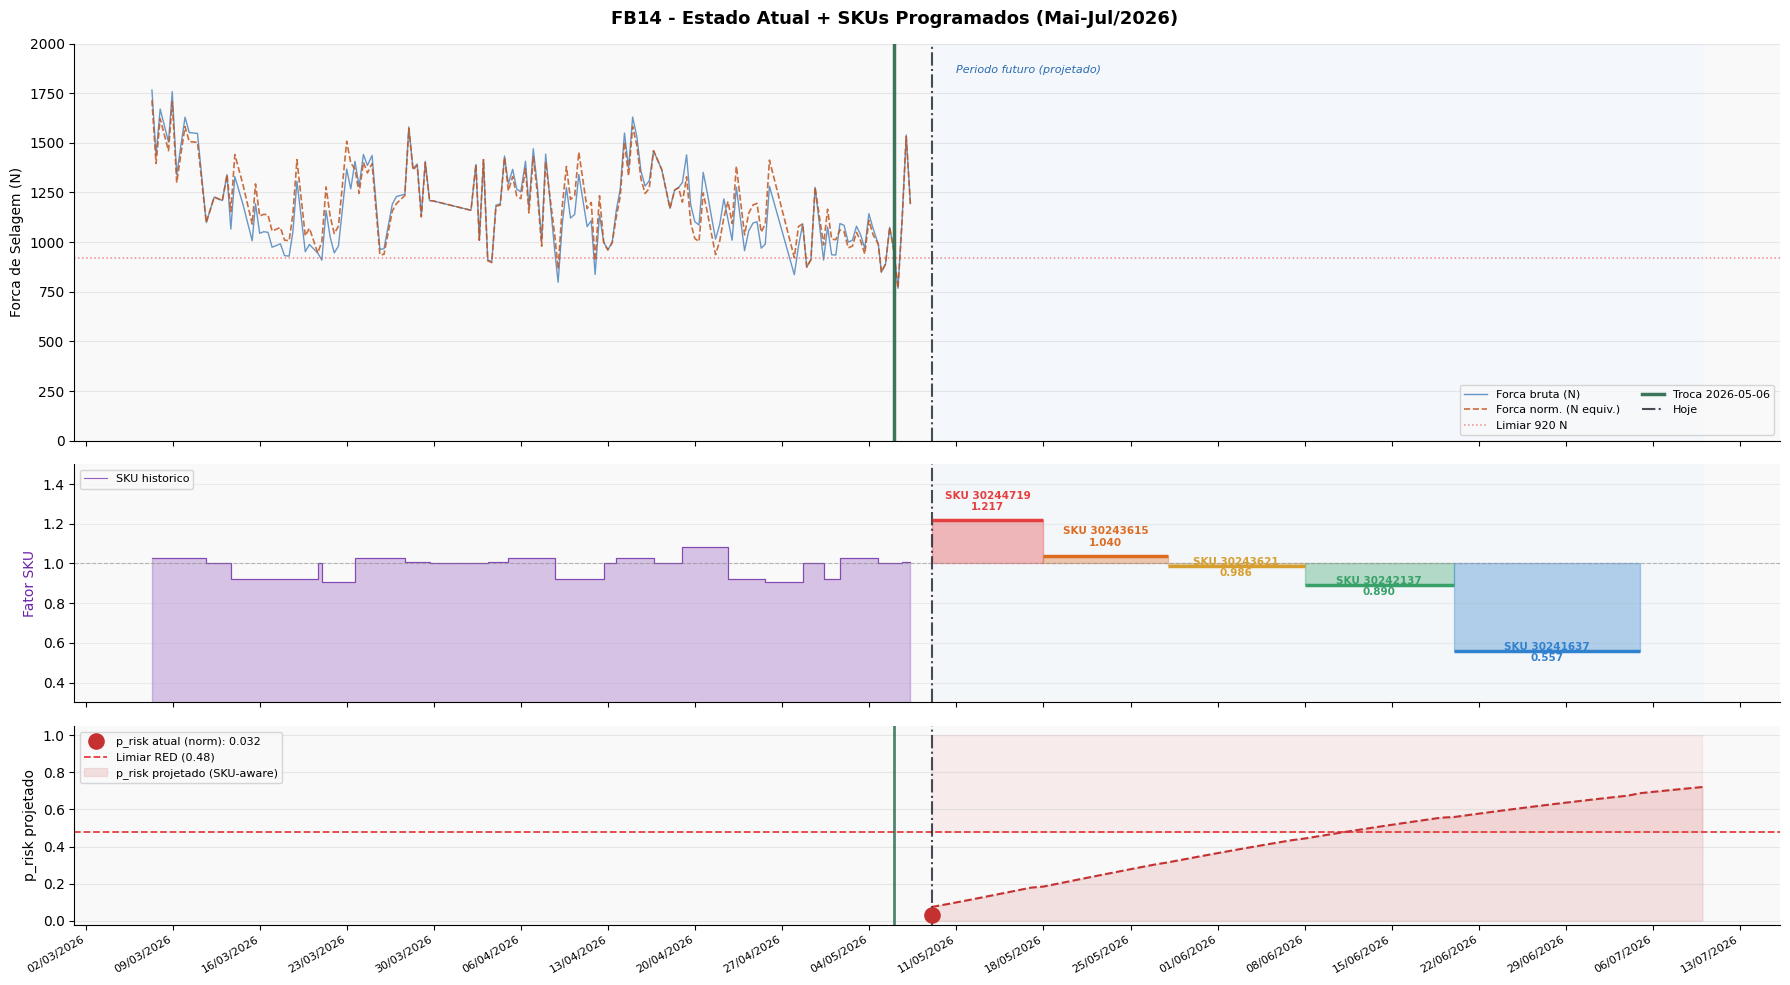

Figura 3 salva: 07_sku_aware_forecast.png


In [12]:
# Figura 3: timeline pos-troca + SKUs futuros
VIS_INI = ultima_troca - timedelta(days=60)
VIS_FIM = ultima_troca + timedelta(days=65)

df_v2  = hora[(hora.index >= VIS_INI) & (hora.index <= VIS_FIM)]
df_v2n = df_engine_norm[(df_engine_norm.index >= VIS_INI) & (df_engine_norm.index <= VIS_FIM)]

fig, axes = plt.subplots(3, 1, figsize=(18, 10),
                          gridspec_kw={'height_ratios':[2,1.2,1]}, sharex=True)
fig.patch.set_facecolor('white')
fig.suptitle('FB14 - Estado Atual + SKUs Programados (Mai-Jul/2026)',
             fontsize=13, fontweight='bold')

# Painel 1: forca bruta + normalizada
ax0 = axes[0]
mask  = df_v2['Media'].notna()
ax0.plot(df_v2[mask].index, df_v2[mask]['Media'], lw=1.0, color=COR_RAW, alpha=0.7, label='Forca bruta (N)')
mask2 = df_v2n['Media'].notna()
ax0.plot(df_v2n[mask2].index, df_v2n[mask2]['Media'], lw=1.2, color=COR_NORM, alpha=0.85,
         label='Forca norm. (N equiv.)', ls='--')
ax0.axhline(920, color=COR_RED, ls=':', lw=1.1, alpha=0.6, label='Limiar 920 N')
ax0.axvline(ultima_troca, color=COR_TROCA, lw=2.5, alpha=0.9, label='Troca 2026-05-06')
ax0.axvline(hoje, color='#1A202C', lw=1.5, ls='-.', alpha=0.8, label='Hoje')
ax0.axvspan(hoje, VIS_FIM, color='#EBF4FF', alpha=0.35, zorder=0)
ax0.set_ylim(0, 2000)
ax0.set_ylabel('Forca de Selagem (N)', fontsize=10)
ax0.legend(fontsize=8, loc='lower right', ncol=2)
ax0.grid(axis='y', alpha=0.25)
ax0.text(hoje + timedelta(days=2), 1850, 'Periodo futuro (projetado)',
         fontsize=8, color='#2B6CB0', style='italic')

# Painel 2: fator SKU historico + futuros
ax1 = axes[1]
df_fator = df_norm[(df_norm.index >= VIS_INI) & (df_norm.index <= VIS_FIM)]
mask3 = df_fator['sku_fator'].notna()
ax1.fill_between(df_fator[mask3].index, df_fator[mask3]['sku_fator'], color=COR_SKU, alpha=0.25, step='post')
ax1.plot(df_fator[mask3].index, df_fator[mask3]['sku_fator'], lw=0.8, color=COR_SKU, alpha=0.7,
         drawstyle='steps-post', label='SKU historico')
ax1.axhline(1.0, color='gray', ls='--', lw=0.8, alpha=0.5)
ax1.axvline(hoje, color='#1A202C', lw=1.5, ls='-.', alpha=0.8)
ax1.axvspan(hoje, VIS_FIM, color='#EBF4FF', alpha=0.3, zorder=0)

cores_up = ['#E53E3E','#DD6B20','#D69E2E','#38A169','#3182CE']
for j, item in enumerate(UPCOMING_SKUS):
    ini = pd.Timestamp(item['data_inicio'])
    fim = pd.Timestamp(item['data_fim'])
    if fim < VIS_INI or ini > VIS_FIM: continue
    f_sku = get_sku_factor(item['sku'])
    ini_c = max(ini, hoje)
    fim_c = min(fim, VIS_FIM)
    cor = cores_up[j % len(cores_up)]
    ax1.fill_between([ini_c, fim_c], [f_sku, f_sku], [1.0, 1.0], color=cor, alpha=0.35)
    ax1.hlines(f_sku, ini_c, fim_c, colors=cor, linewidths=2.5)
    mid = ini_c + (fim_c - ini_c) / 2
    label_y = f_sku + (0.04 if f_sku >= 1.0 else -0.06)
    ax1.text(mid, label_y, f"SKU {item['sku']}\n{f_sku:.3f}",
             ha='center', va='bottom', fontsize=7.5, color=cor, fontweight='bold')

ax1.set_ylim(0.3, 1.5)
ax1.set_ylabel('Fator SKU', fontsize=10, color=COR_SKU)
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.2)

# Painel 3: p_risk projetado
ax2 = axes[2]
prisk_atual = snap_norm_.get('p_risk', 0) or 0
ax2.scatter([hoje], [prisk_atual], color=COR_PRISK, s=120, zorder=6,
            label=f'p_risk atual (norm): {prisk_atual:.3f}')
ax2.axhline(LIMIAR_P_RISK, color=COR_RED, ls='--', lw=1.3, label=f'Limiar RED ({LIMIAR_P_RISK})')

datas_proj = pd.date_range(hoje, VIS_FIM, freq='D')
prisk_proj = []
sig_base = snap_norm_.get('signal_score', 0.05) or 0.05
for dp in datas_proj:
    age_d = (dp - ultima_troca).days
    ar = float(1 - np.exp(-((max(age_d, 0) / WEIBULL_ETA_D) ** WEIBULL_BETA)))
    uf_dp = upcoming_sku_factor(dp, janela_dias=1)
    sig_aj = min(1.0, sig_base * (uf_dp ** 1.5))
    prisk_proj.append(ar + (1 - ar) * sig_aj * 0.65)

ax2.fill_between(datas_proj, prisk_proj, color=COR_PRISK, alpha=0.12, label='p_risk projetado (SKU-aware)')
ax2.plot(datas_proj, prisk_proj, lw=1.5, color=COR_PRISK, ls='--')
ax2.fill_between(datas_proj, LIMIAR_P_RISK, 1.0, alpha=0.07, color=COR_RED)
ax2.axvline(ultima_troca, color=COR_TROCA, lw=2.0, alpha=0.8)
ax2.axvline(hoje, color='#1A202C', lw=1.5, ls='-.', alpha=0.8)
ax2.set_ylim(-0.02, 1.05)
ax2.set_ylabel('p_risk projetado', fontsize=10)
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(axis='y', alpha=0.25)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=1))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('07_sku_aware_forecast.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Figura 3 salva: 07_sku_aware_forecast.png')


In [13]:
# Resumo executivo
print('=' * 62)
print('  RESUMO: SKU-AWARE TRIGGER ENGINE v3')
print('=' * 62)
print()
print(f"Catalogo: {len(SKU_CATALOG)} SKUs  |  range fator: "
      f"{min(SKU_CATALOG.values()):.3f} a {max(SKU_CATALOG.values()):.3f}  "
      f"({max(SKU_CATALOG.values())/min(SKU_CATALOG.values()):.2f}x)")
print()
print('Backtest:')
for nome, ev in [('v2 raw', ev_raw), ('v3 norm', ev_norm)]:
    if ev.empty: print(f'  {nome}: sem eventos'); continue
    print(f"  {nome}: {len(ev):>3} alertas | {ev['ciclo'].nunique()}/30 ciclos | "
          f"antecedencia mediana {ev['ant'].median():.0f}d")
print()
print('SKUs futuros simulados (proximos 60d):')
for item in UPCOMING_SKUS:
    f = get_sku_factor(item['sku'])
    print(f"  {item['data_inicio']} -> {item['data_fim']}  SKU {item['sku']}  fator={f:.3f}")
print()
print('Proximo passo: substituir lista simulada por dados reais do PP/SAP')
print('  -> src/sku_normalizer.py : UPCOMING_SKUS[]')


  RESUMO: SKU-AWARE TRIGGER ENGINE v3

Catalogo: 20 SKUs  |  range fator: 0.557 a 1.217  (2.18x)

Backtest:
  v2 raw:  62 alertas | 16/30 ciclos | antecedencia mediana 28d
  v3 norm:  61 alertas | 16/30 ciclos | antecedencia mediana 26d

SKUs futuros simulados (proximos 60d):
  2026-05-09 -> 2026-05-18  SKU 30244719  fator=1.217
  2026-05-18 -> 2026-05-28  SKU 30243615  fator=1.040
  2026-05-28 -> 2026-06-08  SKU 30243621  fator=0.986
  2026-06-08 -> 2026-06-20  SKU 30242137  fator=0.890
  2026-06-20 -> 2026-07-05  SKU 30241637  fator=0.557

Proximo passo: substituir lista simulada por dados reais do PP/SAP
  -> src/sku_normalizer.py : UPCOMING_SKUS[]
